# 04 — Random Walk
**Week 2 | Mathematical Foundations for RL**

Random walks appear everywhere in RL — from the way an agent explores to the theoretical analysis
of TD learning. They also give great intuition about variance in stochastic processes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(7)

## 1. Simple 1D Random Walk
At each step: move +1 (right) or -1 (left) with equal probability.

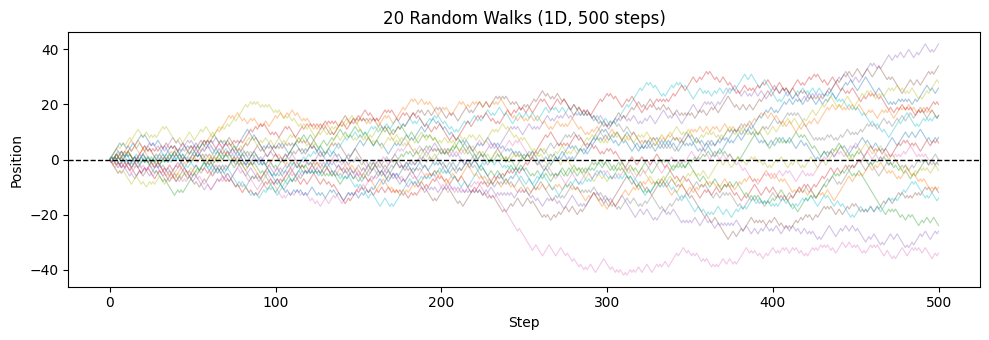

In [2]:
def random_walk_1d(n_steps, p_right=0.5):
    steps = np.where(np.random.rand(n_steps) < p_right, 1, -1)
    return np.concatenate([[0], np.cumsum(steps)])

n_steps = 500
fig, ax = plt.subplots(figsize=(10, 3.5))
for i in range(20):
    walk = random_walk_1d(n_steps)
    ax.plot(walk, alpha=0.4, linewidth=0.8)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Step'); ax.set_ylabel('Position')
ax.set_title('20 Random Walks (1D, 500 steps)')
plt.tight_layout(); plt.show()

## 2. Distribution of Positions at Time t
At time t, position X_t ~ N(0, t) — variance grows linearly with time.

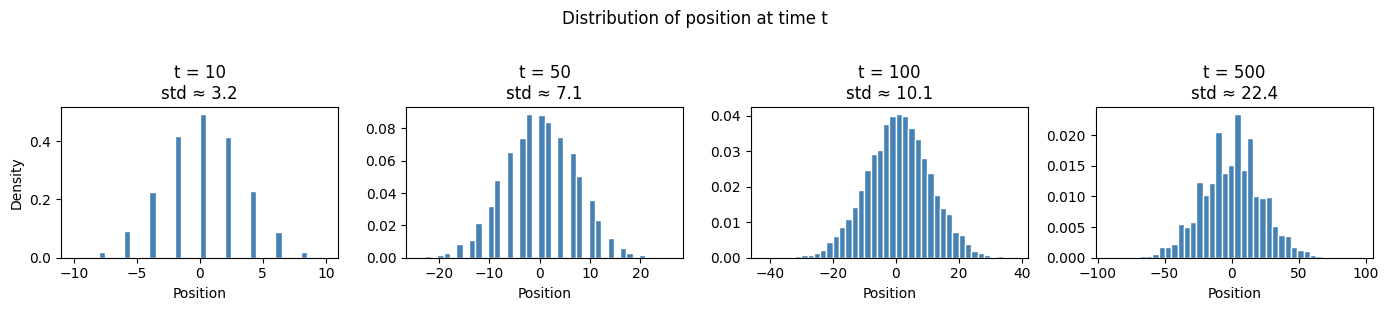

Theoretical std = sqrt(t): ['10→3.2', '50→7.1', '100→10.0', '500→22.4']


In [3]:
checkpoints = [10, 50, 100, 500]
n_walks = 10_000
fig, axes = plt.subplots(1, len(checkpoints), figsize=(14, 3), sharey=False)

for ax, t in zip(axes, checkpoints):
    positions = [random_walk_1d(t)[-1] for _ in range(n_walks)]
    ax.hist(positions, bins=40, color='steelblue', edgecolor='white', density=True)
    ax.set_title(f't = {t}\nstd ≈ {np.std(positions):.1f}')
    ax.set_xlabel('Position')

axes[0].set_ylabel('Density')
plt.suptitle('Distribution of position at time t', y=1.02)
plt.tight_layout(); plt.show()
print("Theoretical std = sqrt(t):", [f"{t}→{t**0.5:.1f}" for t in checkpoints])

## 3. Biased Random Walk
What if the agent has a preference? (p_right > 0.5)

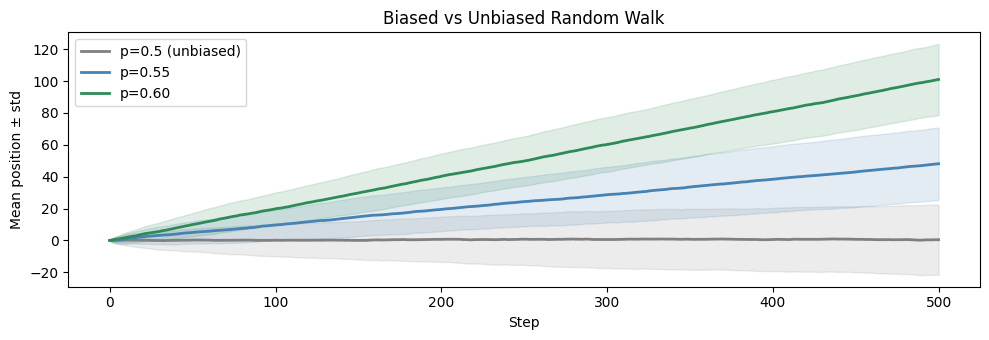

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for p, color, label in [(0.5,'gray','p=0.5 (unbiased)'), (0.55,'steelblue','p=0.55'), (0.6,'seagreen','p=0.60')]:
    walks = np.array([random_walk_1d(500, p) for _ in range(500)])
    mean_walk = walks.mean(axis=0)
    std_walk  = walks.std(axis=0)
    x = np.arange(501)
    ax.plot(mean_walk, color=color, linewidth=2, label=label)
    ax.fill_between(x, mean_walk-std_walk, mean_walk+std_walk, alpha=0.15, color=color)
ax.set_xlabel('Step'); ax.set_ylabel('Mean position ± std')
ax.set_title('Biased vs Unbiased Random Walk')
ax.legend(); plt.tight_layout(); plt.show()

## 4. First Passage Time
How long until the walk reaches position +10 for the first time?

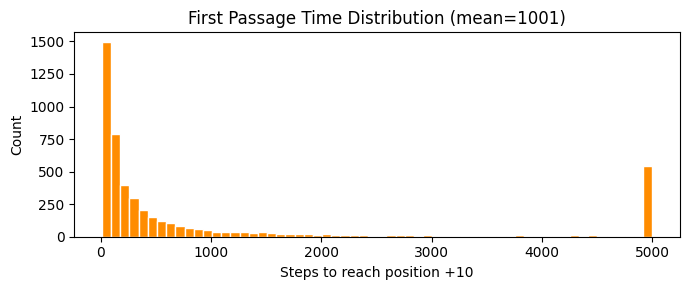

In [5]:
def first_passage_time(target=10, max_steps=5000):
    pos = 0
    for t in range(1, max_steps+1):
        pos += np.random.choice([-1, 1])
        if pos >= target:
            return t
    return max_steps  # didn't reach target

fpt = [first_passage_time(10) for _ in range(5000)]
plt.figure(figsize=(7, 3))
plt.hist(fpt, bins=60, color='darkorange', edgecolor='white')
plt.xlabel('Steps to reach position +10'); plt.ylabel('Count')
plt.title(f'First Passage Time Distribution (mean={np.mean(fpt):.0f})')
plt.tight_layout(); plt.show()

## ✅ Exercises
1. Modify the 1D walk to stop when it hits +20 or -20. What fraction of walks end at +20 vs -20?
2. Simulate a **2D random walk** (move up/down/left/right). Plot 5 trajectories on an x-y grid.
3. **Challenge**: implement the classic '5-state random walk' from Sutton & Barto Example 6.2. States A–E, terminal states at each end. Compute true state values analytically and verify empirically.

Fraction ending at +20 : 0.509
Fraction ending at -20 : 0.491


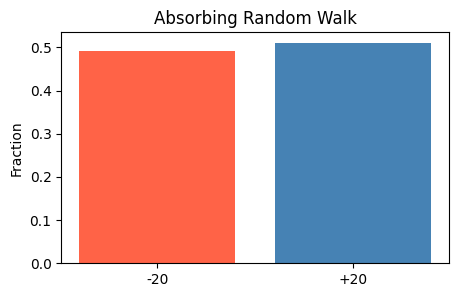

In [6]:
def random_walk_until_boundary(boundary=20):
    pos = 0
    while abs(pos) < boundary:
        pos += np.random.choice([-1, 1])
    return pos

n_walks = 10000
results = np.array([random_walk_until_boundary() for _ in range(n_walks)])

p_plus = np.mean(results == 20)
p_minus = np.mean(results == -20)

print(f"Fraction ending at +20 : {p_plus:.3f}")
print(f"Fraction ending at -20 : {p_minus:.3f}")

plt.figure(figsize=(5,3))
plt.bar(["-20", "+20"], [p_minus, p_plus], color=["tomato","steelblue"])
plt.ylabel("Fraction")
plt.title("Absorbing Random Walk")
plt.show()

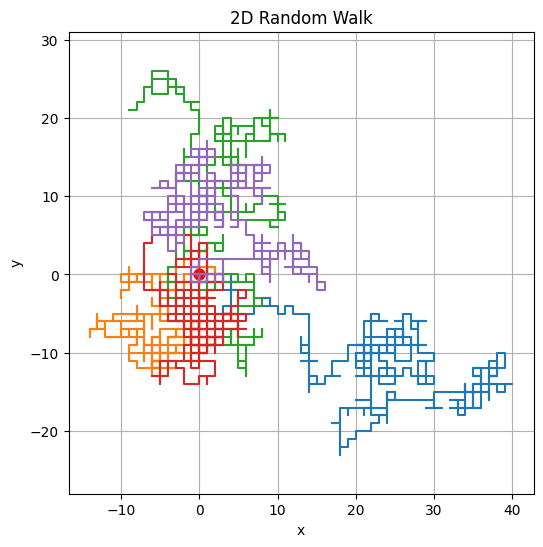

In [7]:
def random_walk_2d(n_steps):
    x = np.zeros(n_steps + 1)
    y = np.zeros(n_steps + 1)

    for i in range(1, n_steps + 1):
        move = np.random.randint(4)

        if move == 0:
            x[i] = x[i-1] + 1
            y[i] = y[i-1]
        elif move == 1:
            x[i] = x[i-1] - 1
            y[i] = y[i-1]
        elif move == 2:
            x[i] = x[i-1]
            y[i] = y[i-1] + 1
        else:
            x[i] = x[i-1]
            y[i] = y[i-1] - 1

    return x, y

plt.figure(figsize=(6,6))

for _ in range(5):
    x, y = random_walk_2d(500)
    plt.plot(x, y)

plt.scatter(0, 0, c="red", s=60)
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Random Walk")
plt.axis("equal")
plt.grid(True)
plt.show()

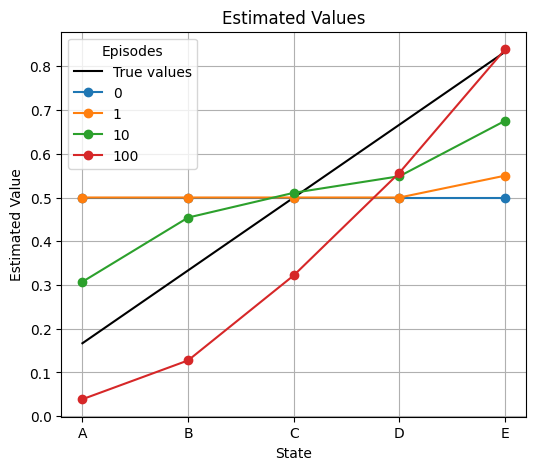

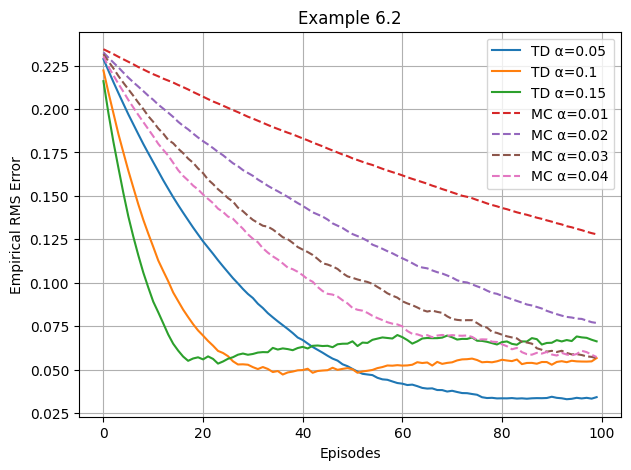

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Environment
# =====================================================

TRUE_VALUES = np.array([1,2,3,4,5]) / 6

N_STATES = 5

def generate_episode():
    """
    States:
    0 = Left terminal
    1 = A
    2 = B
    3 = C
    4 = D
    5 = E
    6 = Right terminal
    """

    state = 3                 # Start at C
    episode = []

    while True:

        next_state = state + np.random.choice([-1,1])

        reward = 1 if next_state == 6 else 0

        episode.append((state,reward))

        if next_state==0 or next_state==6:
            break

        state = next_state

    return episode


# =====================================================
# TD(0)
# =====================================================

def TD(alpha,n_episodes):

    V = np.ones(N_STATES)*0.5

    history = {0:V.copy()}

    for episode in range(1,n_episodes+1):

        traj = generate_episode()

        for i in range(len(traj)):

            state,reward = traj[i]

            if i==len(traj)-1:

                target = reward

            else:

                next_state,_ = traj[i+1]
                target = reward + V[next_state-1]

            V[state-1] += alpha*(target-V[state-1])

        if episode in [1,10,100]:
            history[episode]=V.copy()

    return history


# =====================================================
# Constant-alpha Monte Carlo
# =====================================================

def MC(alpha,n_episodes):

    V = np.ones(N_STATES)*0.5

    rms = np.zeros(n_episodes)

    for episode in range(n_episodes):

        traj = generate_episode()

        G = traj[-1][1]

        visited = []

        for state,reward in traj:

            if state not in visited:
                V[state-1] += alpha*(G-V[state-1])
                visited.append(state)

        rms[episode] = np.sqrt(np.mean((V-TRUE_VALUES)**2))

    return rms


# =====================================================
# TD learning curve
# =====================================================

def TD_curve(alpha,n_episodes):

    V = np.ones(N_STATES)*0.5

    rms = np.zeros(n_episodes)

    for episode in range(n_episodes):

        traj = generate_episode()

        for i in range(len(traj)):

            state,reward = traj[i]

            if i==len(traj)-1:

                target = reward

            else:

                next_state,_ = traj[i+1]
                target = reward + V[next_state-1]

            V[state-1] += alpha*(target-V[state-1])

        rms[episode]=np.sqrt(np.mean((V-TRUE_VALUES)**2))

    return rms


# =====================================================
# Left Figure
# =====================================================

history = TD(0.1,100)

plt.figure(figsize=(6,5))

labels = list("ABCDE")

plt.plot(labels,TRUE_VALUES,'k-',label='True values')

plt.plot(labels,history[0],'o-',label='0')
plt.plot(labels,history[1],'o-',label='1')
plt.plot(labels,history[10],'o-',label='10')
plt.plot(labels,history[100],'o-',label='100')

plt.title("Estimated Values")
plt.xlabel("State")
plt.ylabel("Estimated Value")
plt.legend(title="Episodes")
plt.grid(True)

plt.show()


# =====================================================
# Right Figure
# =====================================================

N_RUNS = 100
N_EPISODES = 100

plt.figure(figsize=(7,5))

# ---------- TD ----------
for alpha in [0.05,0.1,0.15]:

    rms = np.zeros(N_EPISODES)

    for run in range(N_RUNS):
        rms += TD_curve(alpha,N_EPISODES)

    rms /= N_RUNS

    plt.plot(rms,label=f"TD α={alpha}")

# ---------- MC ----------
for alpha in [0.01,0.02,0.03,0.04]:

    rms = np.zeros(N_EPISODES)

    for run in range(N_RUNS):
        rms += MC(alpha,N_EPISODES)

    rms /= N_RUNS

    plt.plot(rms,'--',label=f"MC α={alpha}")

plt.xlabel("Episodes")
plt.ylabel("Empirical RMS Error")
plt.title("Example 6.2")
plt.legend()

plt.grid(True)

plt.show()